# Visualization Enhancements

This notebook demonstrates the built-in visualization capabilities of the `stats-transformer` library. 
We will explore how to perform Exploratory Data Analysis (EDA) and visualize econometric model diagnostics seamlessly.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from stats_transformer.data import load_sample_data
from stats_transformer.visualization.eda.data_viz import DataVisualizer
from stats_transformer.models.regression.robust_ols import RobustOLSModel
from stats_transformer.visualization.models.regression_viz import RegressionVisualizer

# Load the sample dataset
df = load_sample_data().dropna()
display(df.head())

,country,date,inflation,gdp
0,ABW,1985,4.032258,68.82939
1,ABW,1986,1.073966,68.82134
2,ABW,1987,3.639953,68.89938
3,ABW,1988,3.121032,68.76744
4,ABW,1989,3.989460,68.79722


## 1. Exploratory Data Analysis (EDA)
Using `DataVisualizer` to generate distributions, scatter plots, and correlation matrices.

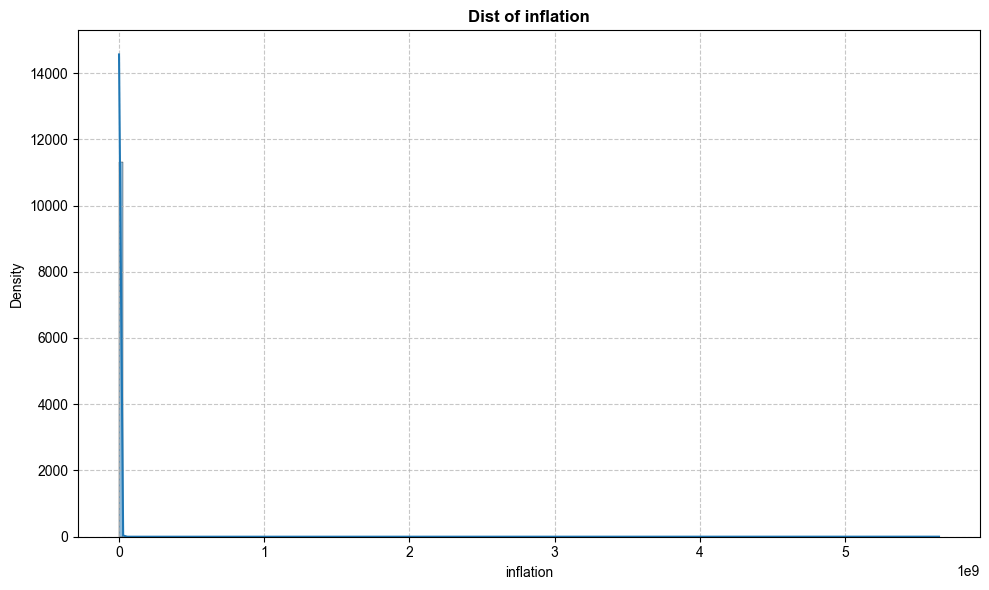

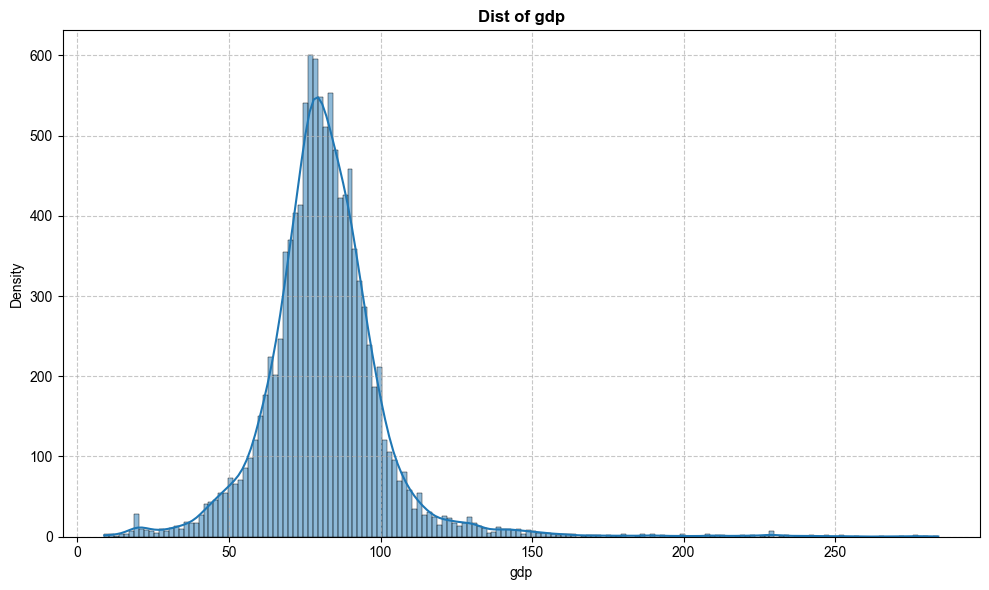

In [2]:
data_viz = DataVisualizer(output_dir='data/notebook_exports/notebook_viz')

# Distribution plot
data_viz.create_visualization(df, feature_list=['inflation', 'gdp'], viz_type='distribution', display_only=True)
plt.show()

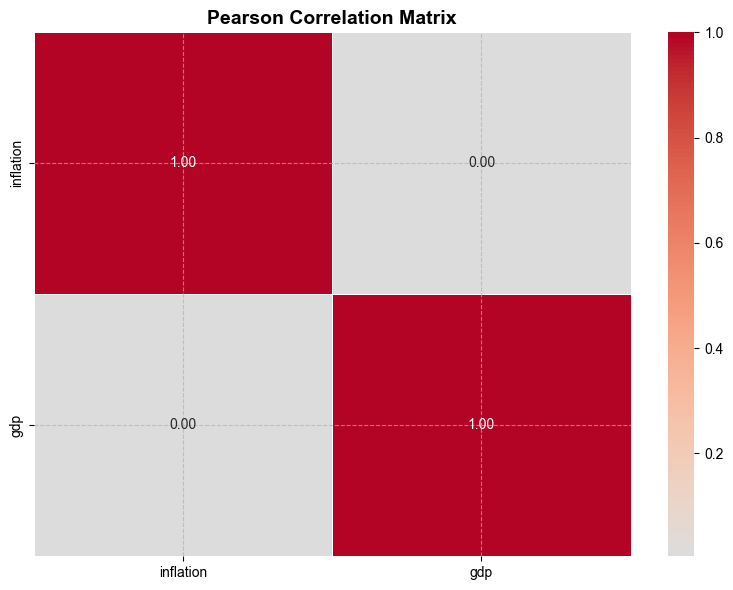

In [3]:
# Correlation matrix
data_viz.create_visualization(df, feature_list=['inflation', 'gdp'], viz_type='correlation', display_only=True)
plt.show()

In [4]:
# Scatter plot
data_viz.create_visualization(df, feature_list=['inflation'], target='gdp', viz_type='scatter')
plt.show()

2026-05-08 14:30:43,407 - INFO - Saved visualization to data/notebook_exports/notebook_viz/scatter_plots/scatter_inflation_vs_gdp.png


## 2. Regression Model Diagnostics
Fit a standard Robust OLS model and visualize its diagnostics. We include entity fixed effects for a more realistic model.

In [5]:
model = RobustOLSModel(
    target='gdp',
    independent_variables=['inflation'],
    add_entity_fixed_effects=True,
    entity_column='country',
    cov_type='HC3'
)
model.fit(df)
print(model.get_summary())

                            OLS Regression Results                            
Dep. Variable:                    gdp   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 08 May 2026   Prob (F-statistic):                nan
Time:                        14:30:44   Log-Likelihood:                -44046.
No. Observations:               11307   AIC:                         8.851e+04
Df Residuals:                   11099   BIC:                         9.003e+04
Df Model:                         207                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
inflation    1.18e-10      0.000   5.46e-07      1.0

In [6]:
reg_viz = RegressionVisualizer(output_dir='data/notebook_exports/notebook_viz')

# Model Summary Table
reg_viz.visualize_from_json(model_summary=model.get_summary(), display_only=True)
plt.show()

2026-05-08 14:30:45,203 - INFO - Creating coefficient plot from JSON
2026-05-08 14:30:45,204 - WARNING - No coefficients found in model_summary
2026-05-08 14:30:45,204 - INFO - Creating model summary plot
2026-05-08 14:30:45,204 - ERROR - Error creating model summary plot: 'str' object has no attribute 'get'


2026-05-08 14:30:46,324 - INFO - Creating actual vs predicted scatter plot


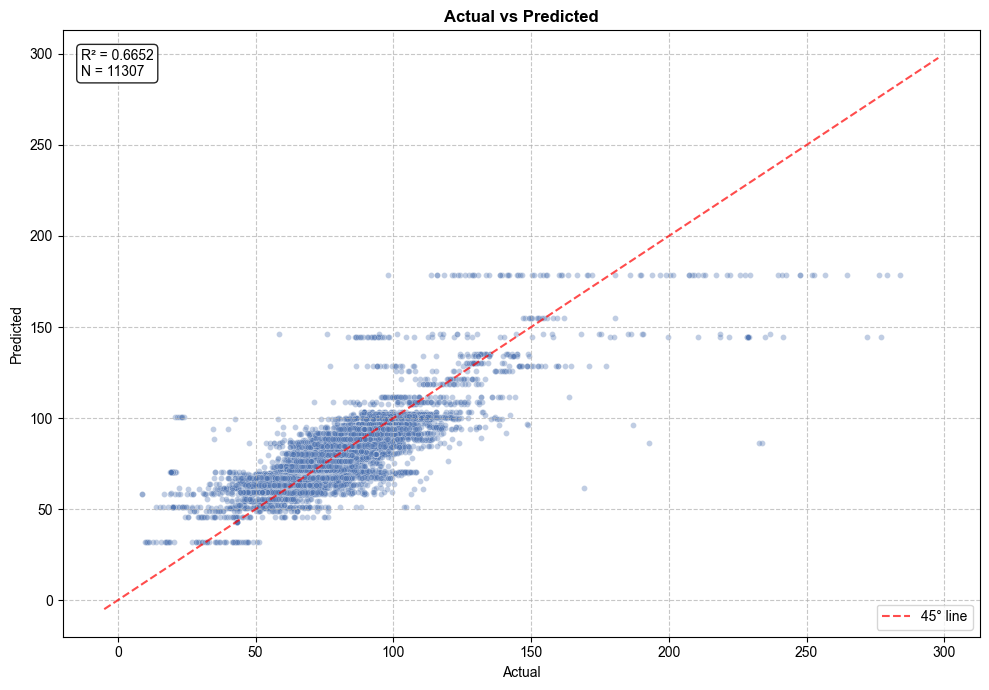

In [7]:
# Actual vs Predicted
reg_viz.create_actual_vs_predicted(model.model, display_only=True)
plt.show()

2026-05-08 14:30:46,882 - INFO - Creating residuals vs fitted scatter plot
2026-05-08 14:30:46,887 - INFO - Downsampling for LOWESS calculation (11307 -> 800)


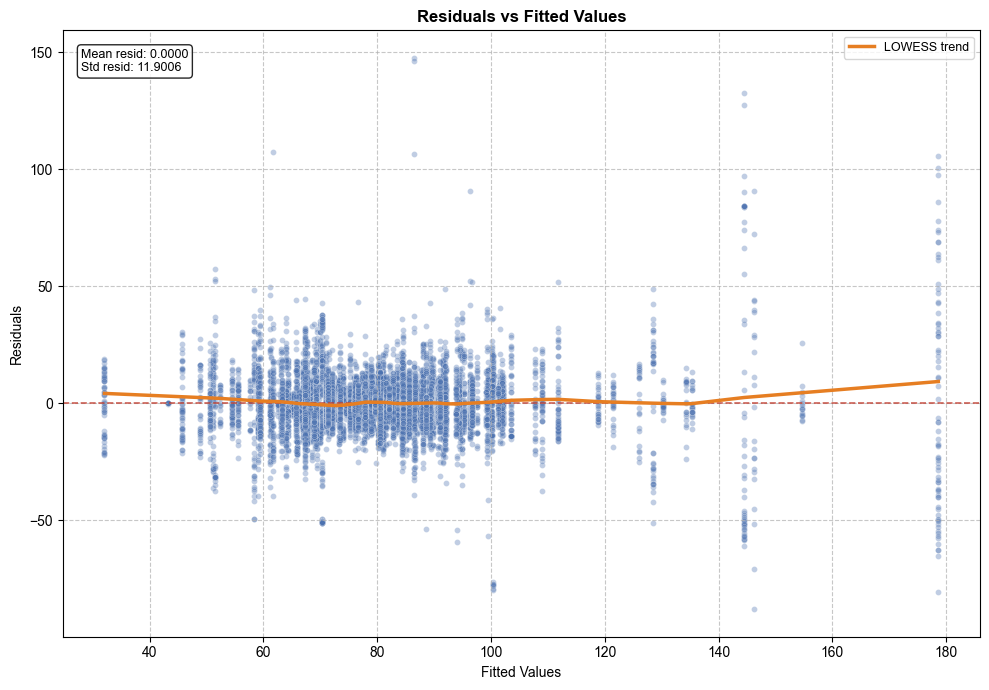

In [8]:
# Residuals vs Fitted
reg_viz.create_residuals_vs_fitted(model.model, display_only=True)
plt.show()